# Mean Shift Clustering from Scratch

Mean Shift finds clusters by looking for the places where the data is densest.

Picture a smooth surface laid over the data, high where points are crowded and low where they are
sparse. Formally that surface is a kernel density estimate,

$$\hat{f}(x) = \frac{1}{n}\sum_{i=1}^{n} K\!\left(\frac{\lVert x - x_i \rVert}{h}\right)$$

with $h$ the **bandwidth**. This notebook uses a Gaussian kernel, so a point $x_i$ contributes

$$w_i(c) = \exp\!\left(-\frac{\lVert x_i - c \rVert^2}{2h^2}\right)$$

to a centroid sitting at $c$. Nearby points contribute close to 1 and distant ones close to 0.

The algorithm moves each centroid to the weighted average of all the data:

$$c \leftarrow m(c) = \frac{\sum_{i=1}^{n} w_i(c)\, x_i}{\sum_{i=1}^{n} w_i(c)}$$

The step it just took, $m(c) - c$, is the **mean shift vector**, and it points along the gradient
of the density:

$$m(c) - c \;\propto\; \frac{\nabla \hat{f}(c)}{\hat{f}(c)}$$

So repeating the update is gradient ascent on $\hat f$ with the step size chosen for you - every
centroid climbs uphill until it reaches a peak, where the weighted average of its neighbourhood is
the place it already stands and $m(c) = c$. Centroids that arrive at the same peak are merged, and
the peaks that survive are the clusters.

The number of clusters is never supplied. Only $h$ is, which sets how far a centroid looks.

Compare that with K-Means, which minimises

$$J = \sum_{j}\sum_{x \in C_j} \lVert x - \mu_j \rVert^2$$

Every point assigned to a centroid counts equally there no matter how far away it is, and $k$ has
to be fixed in advance. Those two differences are what this notebook is about.

It runs on the Skin Segmentation dataset, where pixels are labelled skin or not-skin from their
blue, green and red values. K-Means is run on the same data for comparison, because this is a case
where the two behave very differently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

colors = 10 * ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']

## Loading the data

`fetch_ucirepo(id=229)` downloads 245,057 pixels, each with a blue, green and red value and a
label of `1` for skin or `2` for not-skin.

Both algorithms here compare every point against every other point on each pass, so the cost grows
with the square of the number of rows. The cell takes a random sample of 800 pixels, which is
enough to show the structure and keeps the notebook to a few seconds.

The three channels are then put on the same scale by subtracting the mean and dividing by the
standard deviation, so no single colour channel dominates the distance calculation.

In [2]:
skin = fetch_ucirepo(id=229)

X_all = skin.data.features.values.astype(float)
y_all = skin.data.targets.values.ravel()

# every pass compares all points against all points, so take a sample
rng = np.random.default_rng(0)
sample = rng.choice(len(X_all), 800, replace=False)

X = X_all[sample]
y = y_all[sample]
feature_names = list(skin.data.features.columns)

# put the three channels on the same scale
X = (X - X.mean(axis=0)) / X.std(axis=0)

print('all pixels:', X_all.shape)
print('sample:', X.shape, feature_names)
print('skin (1):    ', (y == 1).sum())
print('not-skin (2):', (y == 2).sum())
print()
print(f'predicting not-skin for everything would already score {(y == 2).mean():.4f}')

all pixels: (245057, 3)
sample: (800, 3) ['B', 'G', 'R']
skin (1):     161
not-skin (2): 639

predicting not-skin for everything would already score 0.7987


## What the data looks like

The cell plots the sample twice, using two of the three channel pairs, coloured by the true label.

The shape is the reason this dataset was chosen. The skin pixels sit in one tight, compact clump.
The not-skin pixels are spread over a much wider area and are not one clump at all - they form
several separate concentrations, because "not skin" covers every other colour there is.

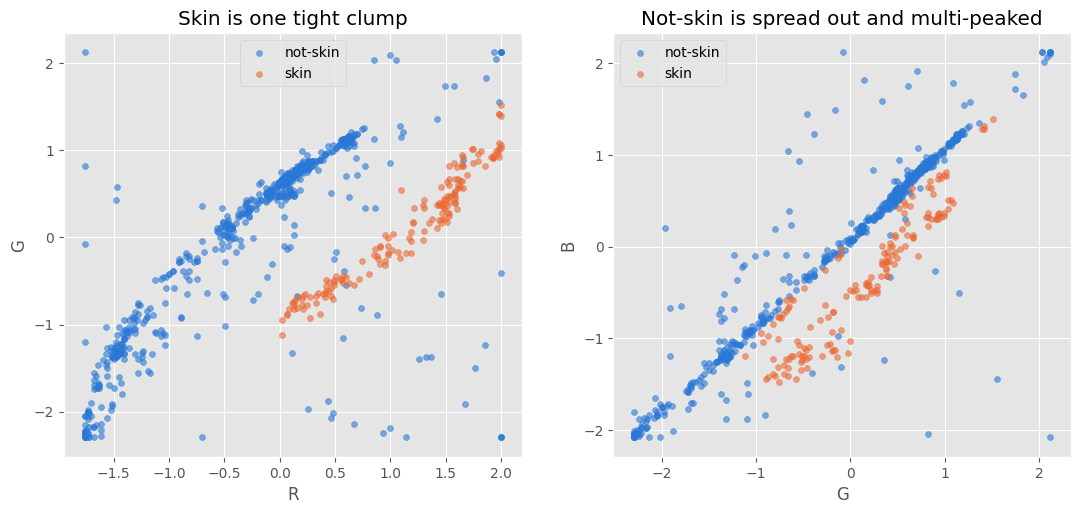

average distance from a point to the centre of its own class:
  skin      0.99
  not-skin  1.50


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

for a, (i, j) in zip(ax, [(2, 1), (1, 0)]):
    for label, color, name in [(2, colors[0], 'not-skin'), (1, colors[1], 'skin')]:
        a.scatter(X[y == label, i], X[y == label, j], color=color, s=18, alpha=0.6, label=name)
    a.set_xlabel(feature_names[i])
    a.set_ylabel(feature_names[j])
    a.legend()

ax[0].set_title('Skin is one tight clump')
ax[1].set_title('Not-skin is spread out and multi-peaked')
plt.show()

print('average distance from a point to the centre of its own class:')
for label, name in [(1, 'skin'), (2, 'not-skin')]:
    spread = np.linalg.norm(X[y == label] - X[y == label].mean(axis=0), axis=1).mean()
    print(f'  {name:9s} {spread:.2f}')

## K-Means first, for comparison

The class below is the same K-Means used elsewhere in this repository. It is given `k=2`, which is
the correct number of classes.

K-Means works by minimising the total squared distance from each point to its centroid, and that
objective quietly assumes the clusters are round and roughly the same size. Neither is true here.

In [4]:
class K_Means:
    def __init__(self, k=2, tol=0.001, max_iter=300):
        self.k = k
        self.tol = tol
        self.max_iter = max_iter

    def fit(self, data):
        self.centroids = {}
        for i in range(self.k):
            self.centroids[i] = data[i]

        for i in range(self.max_iter):
            self.classifications = {}
            for j in range(self.k):
                self.classifications[j] = []

            for featureset in data:
                distances = [np.linalg.norm(featureset - self.centroids[c]) for c in self.centroids]
                self.classifications[distances.index(min(distances))].append(featureset)

            prev_centroids = dict(self.centroids)

            for classification in self.classifications:
                if len(self.classifications[classification]) > 0:
                    self.centroids[classification] = np.average(self.classifications[classification], axis=0)

            optimized = True
            for c in self.centroids:
                if np.sum(np.abs(self.centroids[c] - prev_centroids[c])) > self.tol:
                    optimized = False

            if optimized:
                break

    def predict(self, data):
        distances = [np.linalg.norm(data - self.centroids[c]) for c in self.centroids]
        return distances.index(min(distances))


def accuracy(labels, truth):
    correct = 0
    mapping = {}
    for c in np.unique(labels):
        members = truth[labels == c]
        names, counts = np.unique(members, return_counts=True)
        mapping[c] = names[np.argmax(counts)]
        correct += max(counts)
    return correct / len(truth), mapping


km = K_Means(k=2)
km.fit(X)
km_labels = np.array([km.predict(x) for x in X])
km_acc, _ = accuracy(km_labels, y)

print(f'K-Means accuracy with k=2: {km_acc:.4f}')
print()
for c in sorted(set(km_labels)):
    members = y[km_labels == c]
    print(f'  cluster {c}: {len(members):3d} pixels  '
          f'skin {int((members == 1).sum()):3d}  not-skin {int((members == 2).sum()):3d}')

K-Means accuracy with k=2: 0.7987

  cluster 0: 530 pixels  skin 114  not-skin 416
  cluster 1: 270 pixels  skin  47  not-skin 223


Both clusters come out roughly one-fifth skin, which means neither of them is the skin cluster.
K-Means split the wide not-skin region down the middle and spread the skin pixels across both
halves, because cutting the big diffuse cloud in two lowers the total squared distance more than
carving out the small tight one does.

The accuracy matches the score for labelling everything not-skin, so with `k=2` it has found
nothing useful.

## The Mean_Shift class

`__init__` takes `bandwidth`, the $h$ from above.

`fit` starts with a copy of the data, so there are 800 centroids. Each pass:

- `distances` measures $\lVert x_i - c \rVert$ from the centroid to every data point
- `weights` turns those into $w_i = \exp\!\left(-\dfrac{\lVert x_i - c\rVert^2}{2h^2}\right)$
- the centroid moves to $\dfrac{\sum_i w_i x_i}{\sum_i w_i}$, one step uphill on the density
- `shift` records $\max_j \lVert c_j^{(t)} - c_j^{(t-1)} \rVert_\infty$, and the loop stops once
  that falls below $10^{-4}$

The weighting is the whole difference from K-Means. There a centroid is the plain average

$$\mu_j = \frac{1}{|C_j|}\sum_{x \in C_j} x$$

which gives every assigned point weight 1 and every other point weight 0 - a hard cut-off at the
cluster boundary, with a point just inside counting as much as one at the far edge. Here the weight
decays as $e^{-d^2/2h^2}$, so influence falls away smoothly and a centroid responds to the density
it is standing in rather than to everything on its side of a dividing line.

After the loop, all 800 centroids have piled up on a small number of peaks. The merge step keeps a
centroid only if

$$\lVert c_a - c_b \rVert > \frac{h}{2}$$

against every centroid already kept. The number of survivors is the number of clusters.

In [5]:
class Mean_Shift:
    def __init__(self, bandwidth=0.45, max_iter=100):
        self.bandwidth = bandwidth
        self.max_iter = max_iter

    def fit(self, data):
        # every point starts as its own centroid
        centroids = np.array(data, dtype=float)

        for i in range(self.max_iter):
            new_centroids = np.zeros_like(centroids)

            for j in range(len(centroids)):
                # nearby points get a big weight, distant ones almost none
                distances = np.linalg.norm(data - centroids[j], axis=1)
                weights = np.exp(-(distances ** 2) / (2 * self.bandwidth ** 2))

                # move to the weighted average, which is a step towards the denser side
                new_centroids[j] = (data * weights[:, None]).sum(axis=0) / weights.sum()

            shift = np.abs(new_centroids - centroids).max()
            centroids = new_centroids

            if shift < 1e-4:
                break

        # centroids that climbed to the same peak become one cluster
        merged = []
        for c in centroids:
            if all(np.linalg.norm(c - m) > self.bandwidth / 2 for m in merged):
                merged.append(c)

        self.centroids = {i: merged[i] for i in range(len(merged))}
        self.n_iter = i + 1

    def predict(self, data):
        distances = [np.linalg.norm(data - self.centroids[c]) for c in self.centroids]
        return distances.index(min(distances))

## Running it

No cluster count is passed in - only the bandwidth. The cell prints how many clusters survived the
merge and how the pixels in each one are split between the two labels.

In [6]:
ms = Mean_Shift(bandwidth=0.45)
ms.fit(X)

ms_labels = np.array([ms.predict(x) for x in X])
ms_acc, mapping = accuracy(ms_labels, y)

print('clusters found:', len(ms.centroids), 'in', ms.n_iter, 'passes')
print()
for c in sorted(set(ms_labels)):
    members = y[ms_labels == c]
    skin = int((members == 1).sum())
    not_skin = int((members == 2).sum())
    purity = max(skin, not_skin) / len(members)
    print(f'  cluster {c}: {len(members):3d} pixels  skin {skin:3d}  not-skin {not_skin:3d}  '
          f'purity {purity:.2f}')

print()
print(f'Mean Shift accuracy: {ms_acc:.4f}')

clusters found: 8 in 39 passes

  cluster 0: 407 pixels  skin   0  not-skin 407  purity 1.00
  cluster 1: 187 pixels  skin   0  not-skin 187  purity 1.00
  cluster 2: 102 pixels  skin  96  not-skin   6  purity 0.94
  cluster 3:  86 pixels  skin  65  not-skin  21  purity 0.76
  cluster 4:  14 pixels  skin   0  not-skin  14  purity 1.00
  cluster 5:   1 pixels  skin   0  not-skin   1  purity 1.00
  cluster 6:   2 pixels  skin   0  not-skin   2  purity 1.00
  cluster 7:   1 pixels  skin   0  not-skin   1  purity 1.00

Mean Shift accuracy: 0.9663


Two of the clusters hold nearly all the skin pixels, and the rest are pure not-skin. Mean Shift
found that not-skin is several separate concentrations rather than one, and kept them apart
instead of averaging them together.

## The two side by side

The left panel is what K-Means produced with `k=2`, the middle is Mean Shift, and the right is the
truth.

K-Means drew a straight line through the middle of the data, which is all it can ever do - every
point goes to the closest of two centroids, so the boundary between them is always a straight
divide. Mean Shift has no such constraint, because a point's cluster is decided by which peak it
climbs to.

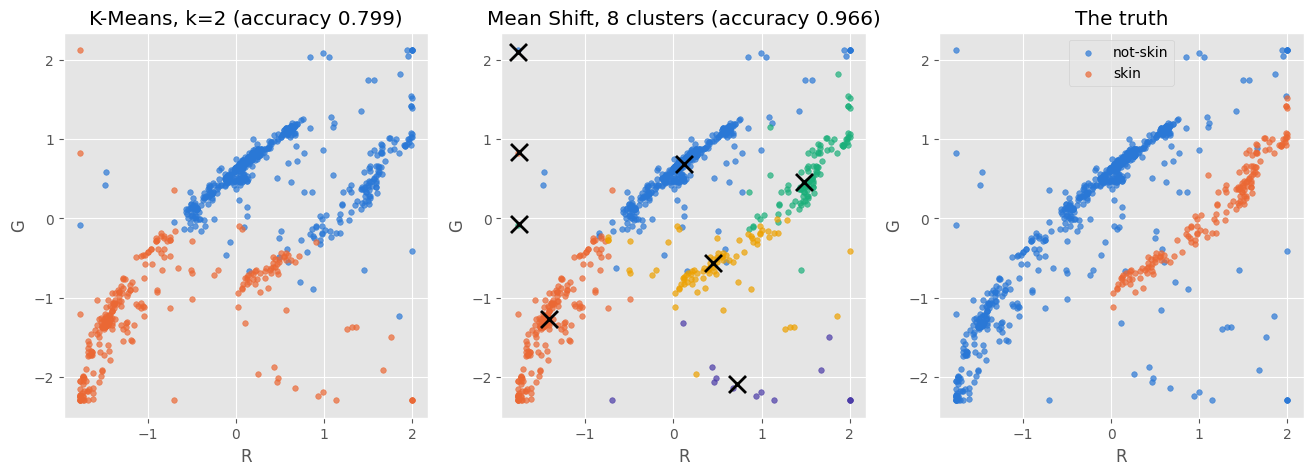

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

for c in sorted(set(km_labels)):
    ax[0].scatter(X[km_labels == c, 2], X[km_labels == c, 1], color=colors[c], s=16, alpha=0.7)
ax[0].set_title(f'K-Means, k=2 (accuracy {km_acc:.3f})')

for c in sorted(set(ms_labels)):
    ax[1].scatter(X[ms_labels == c, 2], X[ms_labels == c, 1], color=colors[c], s=16, alpha=0.7)
for c in ms.centroids:
    ax[1].scatter(ms.centroids[c][2], ms.centroids[c][1], color='k', marker='x', s=150, linewidths=2)
ax[1].set_title(f'Mean Shift, {len(ms.centroids)} clusters (accuracy {ms_acc:.3f})')

for label, color, name in [(2, colors[0], 'not-skin'), (1, colors[1], 'skin')]:
    ax[2].scatter(X[y == label, 2], X[y == label, 1], color=color, s=16, alpha=0.7, label=name)
ax[2].set_title('The truth')
ax[2].legend()

for a in ax:
    a.set_xlabel(feature_names[2])
    a.set_ylabel(feature_names[1])

plt.show()

## What the bandwidth controls

Bandwidth is the one setting, and it decides how many clusters come out, because it decides how
smooth the density surface $\hat f$ is.

As $h \to 0$ the weights $e^{-d^2/2h^2}$ vanish for every point except the centroid's own, so
$\hat f$ becomes a spike at each sample and every point is its own peak. As $h \to \infty$ all the
weights approach 1, the update becomes

$$c \leftarrow \frac{\sum_i x_i}{n}$$

the global mean, so every centroid lands in the same place and one cluster survives. The useful
values sit between those two limits.

The cell refits across a range of bandwidths and records the number of clusters and the accuracy,
with the K-Means score drawn across for reference.

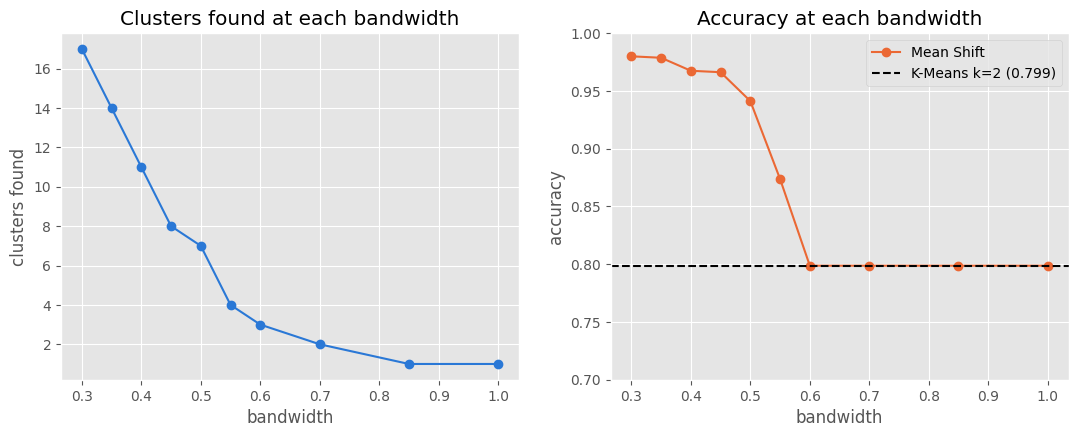

bandwidth 0.30: 17 clusters, accuracy 0.9800
bandwidth 0.35: 14 clusters, accuracy 0.9788
bandwidth 0.40: 11 clusters, accuracy 0.9675
bandwidth 0.45:  8 clusters, accuracy 0.9663
bandwidth 0.50:  7 clusters, accuracy 0.9413
bandwidth 0.55:  4 clusters, accuracy 0.8738
bandwidth 0.60:  3 clusters, accuracy 0.7987
bandwidth 0.70:  2 clusters, accuracy 0.7987
bandwidth 0.85:  1 clusters, accuracy 0.7987
bandwidth 1.00:  1 clusters, accuracy 0.7987


In [8]:
bandwidths = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.85, 1.00]
cluster_counts = []
accuracies = []

for bw in bandwidths:
    m = Mean_Shift(bandwidth=bw)
    m.fit(X)
    lab = np.array([m.predict(x) for x in X])
    cluster_counts.append(len(m.centroids))
    accuracies.append(accuracy(lab, y)[0])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(bandwidths, cluster_counts, marker='o', color=colors[0])
ax[0].set_xlabel('bandwidth')
ax[0].set_ylabel('clusters found')
ax[0].set_title('Clusters found at each bandwidth')

ax[1].plot(bandwidths, accuracies, marker='o', color=colors[1], label='Mean Shift')
ax[1].axhline(km_acc, color='k', linestyle='--', label=f'K-Means k=2 ({km_acc:.3f})')
ax[1].set_xlabel('bandwidth')
ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.7, 1.0)
ax[1].set_title('Accuracy at each bandwidth')
ax[1].legend()

plt.show()

for bw, n, a in zip(bandwidths, cluster_counts, accuracies):
    print(f'bandwidth {bw:.2f}: {n:2d} clusters, accuracy {a:.4f}')

## Being fair to K-Means

Mean Shift found 8 clusters while K-Means was given 2, and a method with more clusters has an
easier time scoring well. The honest comparison is to give K-Means the same number of clusters and
see how it does.

The cell runs K-Means across a range of `k` and plots both.

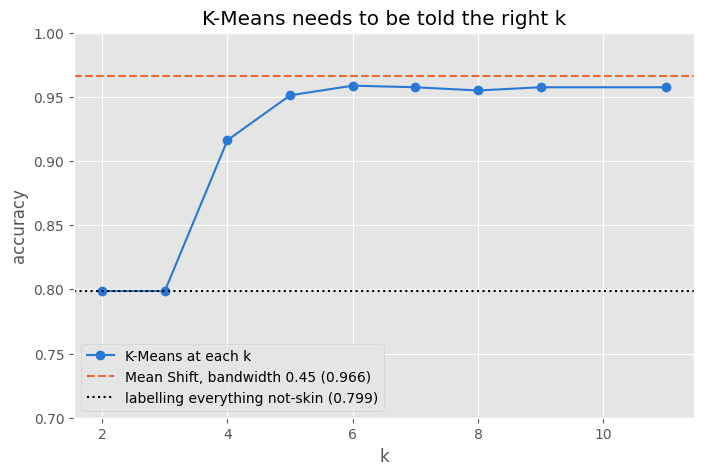

k=2: accuracy 0.7987
k=3: accuracy 0.7987
k=4: accuracy 0.9163
k=5: accuracy 0.9513
k=6: accuracy 0.9587
k=7: accuracy 0.9575
k=8: accuracy 0.9550
k=9: accuracy 0.9575
k=11: accuracy 0.9575


In [9]:
ks = [2, 3, 4, 5, 6, 7, 8, 9, 11]
km_accuracies = []

for k in ks:
    m = K_Means(k=k)
    m.fit(X)
    lab = np.array([m.predict(x) for x in X])
    km_accuracies.append(accuracy(lab, y)[0])

plt.figure(figsize=(8, 5))
plt.plot(ks, km_accuracies, marker='o', color=colors[0], label='K-Means at each k')
plt.axhline(ms_acc, color=colors[1], linestyle='--',
            label=f'Mean Shift, bandwidth 0.45 ({ms_acc:.3f})')
plt.axhline((y == 2).mean(), color='k', linestyle=':',
            label=f'labelling everything not-skin ({(y == 2).mean():.3f})')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.ylim(0.7, 1.0)
plt.title('K-Means needs to be told the right k')
plt.legend()
plt.show()

for k, a in zip(ks, km_accuracies):
    print(f'k={k}: accuracy {a:.4f}')

Given enough clusters, K-Means catches up. The difference is what each method needs to be told.

K-Means only works here at a `k` well above the number of classes, and there is nothing in the
data that announces which `k` that is - picking it means already knowing how the answer should
come out. Mean Shift was given a bandwidth, a statement about how close two pixels have to be to
count as the same colour, and worked the number of groups out for itself.

## Summary

- Mean Shift moves each centroid to a distance-weighted average of the points around it, which
  walks it to the nearest peak in the density. Centroids landing on the same peak are merged.
- It is told a `bandwidth`, not a number of clusters. The cluster count is a result.
- On the skin pixels it finds **8 clusters** and reaches **96.6%**, isolating the skin pixels into
  two of them and leaving the rest pure not-skin.
- K-Means with the correct `k=2` scores **79.9%**, which is the same as labelling every pixel
  not-skin. It splits the large diffuse not-skin region in half instead of separating out the
  small tight skin region, because that lowers the total squared distance more.
- The reason is the weighting. A K-Means centroid is the plain average of everything assigned to
  it, so distant points count as much as near ones. Here the pull falls off with distance, so a
  centroid follows the density it is standing in.